<h1>Using PreTrained Models</h1>

There are some Pre Trained Models available in Keras: https://keras.io/api/applications/

![Screenshot 2026-09-28 090152.png](<attachment:Screenshot 2026-09-28 090152.png>)
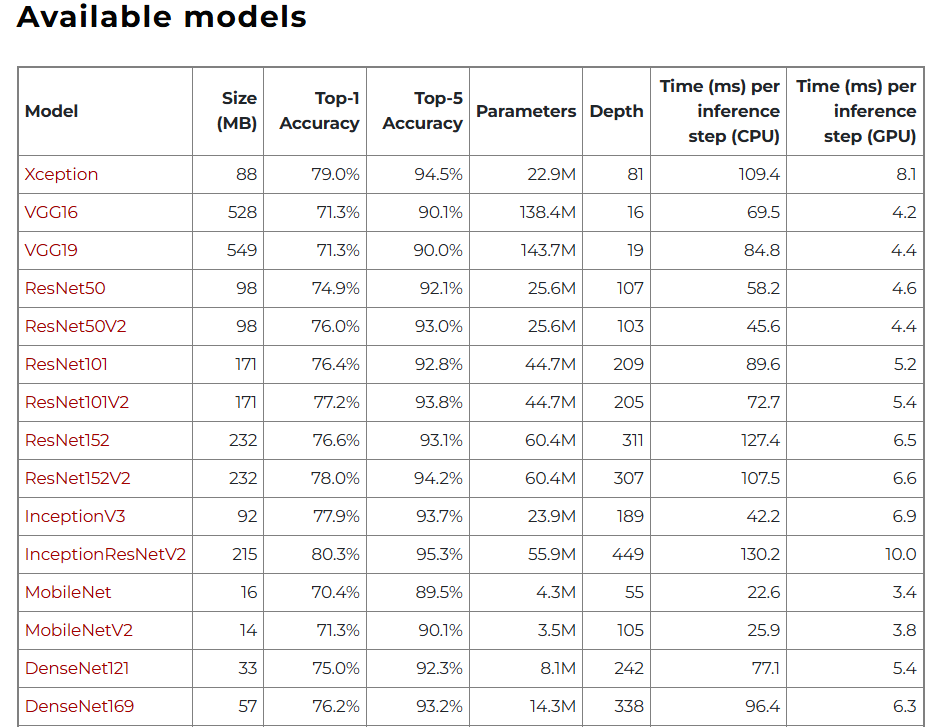

In [36]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input, decode_predictions
import numpy as np

In [ ]:
# Calls Xception model by keras and 
# loads weights learned fron training on Imagenet datset
model = Xception(weights='imagenet')

In [ ]:
img_path = 'cat_image.jpg'      # The image's path
img = image.load_img(img_path, target_size=(299, 299, 3))   # loads the image as PIL Ac to target size
x = image.img_to_array(img)     # convert image to array
x = np.expand_dims(x, axis = 0)     # Adds an extra dimension at the beginning (batch dimension)
x = preprocess_input(x)     # Preprocess the image according to the requirements of the Xception model.

In [ ]:
preds = model.predict(x) # Generate predictions using the Xception model.
# Since ImageNet has 1000 classes, the output for one image is approximately (1, 1000)
# we show only top 3
# decode_predictions() converts these numerical predictions into meaningful ImageNet labels.

print('Predicted: ',decode_predictions(preds, top =3)[0])

# The result contains information such as:(class ID, class name, probability)
# [0] is important because decode_predictions() returns predictions for each image in the batch.
# Since our input has batch size = 1 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
Predicted:  [('n02123045', 'tabby', np.float32(0.5884084)), ('n02123159', 'tiger_cat', np.float32(0.24101871)), ('n02124075', 'Egyptian_cat', np.float32(0.07234948))]


<h1>Vizualizing CNN</h1>

In [ ]:
from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
model1 = VGG16()    # creating another model to visualize what happens in between layers

<h5>See Model's Summary and basic Block Diagram</h5>

In [2]:
model1.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

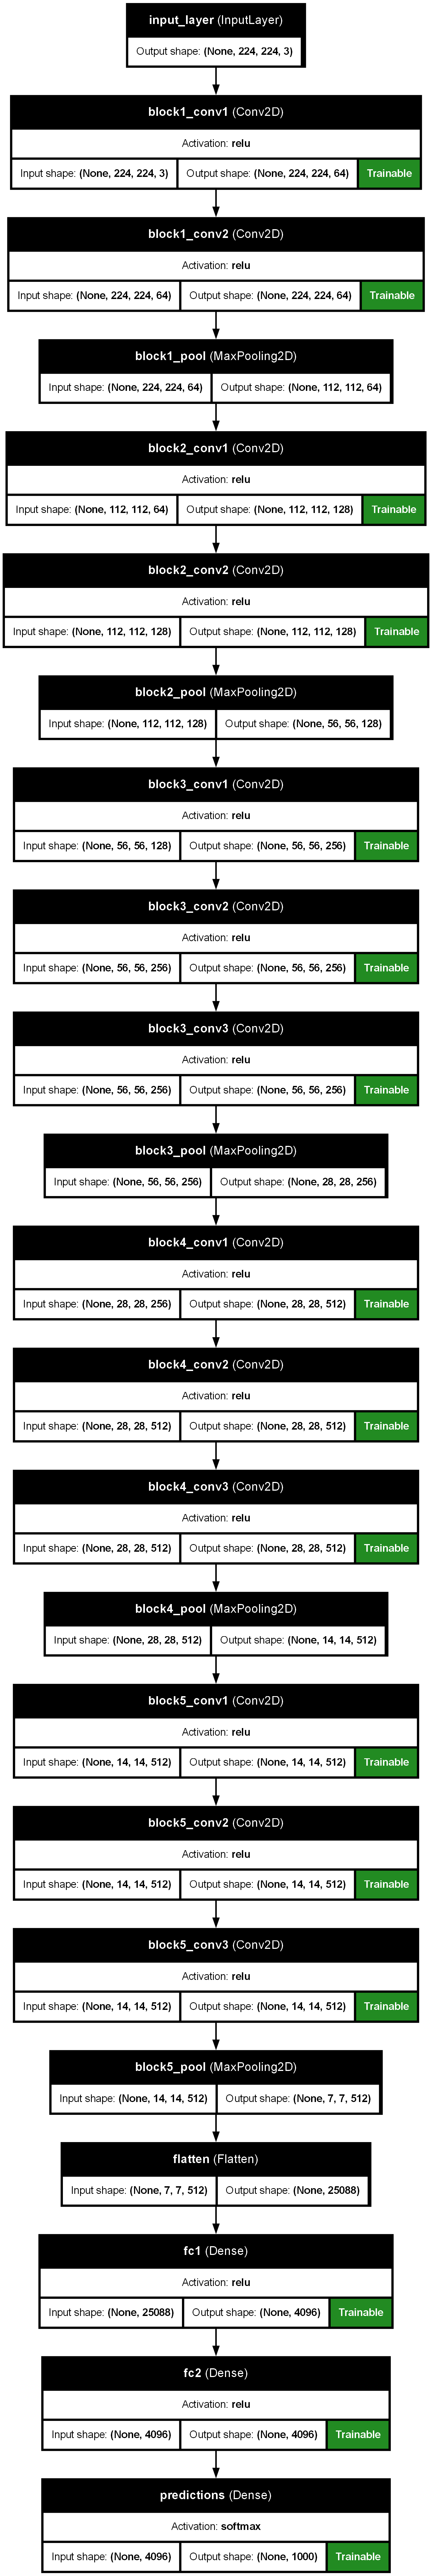

In [ ]:
from keras.utils import plot_model

# plot_model is a utility that creates a visual representation of a neural network model.
plot_model(
    model1,
    show_shapes=True,      # displays the input/output shapes of each layer in the diagram.
    show_layer_names=True,      # display the names of individual layers.
    show_layer_activations=True,    # Shows the activation function used
    show_trainable=True      # Show weather layer is trainable or not
)



In [ ]:
for i in range(len(model1.layers)):     # loops in every layer
    if 'conv' not in model1.layers[i].name:     # if that is not conv layer leave it
        continue
    filters, biases = model1.layers[i].get_weights()    # get the filter and biases o conv layer
    print("layer number", i, model1.layers[i].name, filters.shape)      # print shape of it 

    # (kernel height,kernel width, input channels, number of filters)

layer number 1 block1_conv1 (3, 3, 3, 64)
layer number 2 block1_conv2 (3, 3, 64, 64)
layer number 4 block2_conv1 (3, 3, 64, 128)
layer number 5 block2_conv2 (3, 3, 128, 128)
layer number 7 block3_conv1 (3, 3, 128, 256)
layer number 8 block3_conv2 (3, 3, 256, 256)
layer number 9 block3_conv3 (3, 3, 256, 256)
layer number 11 block4_conv1 (3, 3, 256, 512)
layer number 12 block4_conv2 (3, 3, 512, 512)
layer number 13 block4_conv3 (3, 3, 512, 512)
layer number 15 block5_conv1 (3, 3, 512, 512)
layer number 16 block5_conv2 (3, 3, 512, 512)
layer number 17 block5_conv3 (3, 3, 512, 512)


In [ ]:
# Finding the smallest and largest weight in the entire filter tensor.
print(filters.min())
print(filters.max())

# The filters are not just 0 and 1.
# They contain floating-point numbers learned during training.

filters, bias = model1.layers[1].get_weights()      # lets just see the weights of layer 1

# Normalizing to visualize
# A visualization system generally works conveniently
# With values in a range of [0,1] or [0, 255]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

-0.09288482
0.28699666


In [6]:

print(filters.shape)
print(filters.min())
print(filters.max())

(3, 3, 3, 64)
0.0
1.0


In [7]:
import matplotlib.pyplot as plt

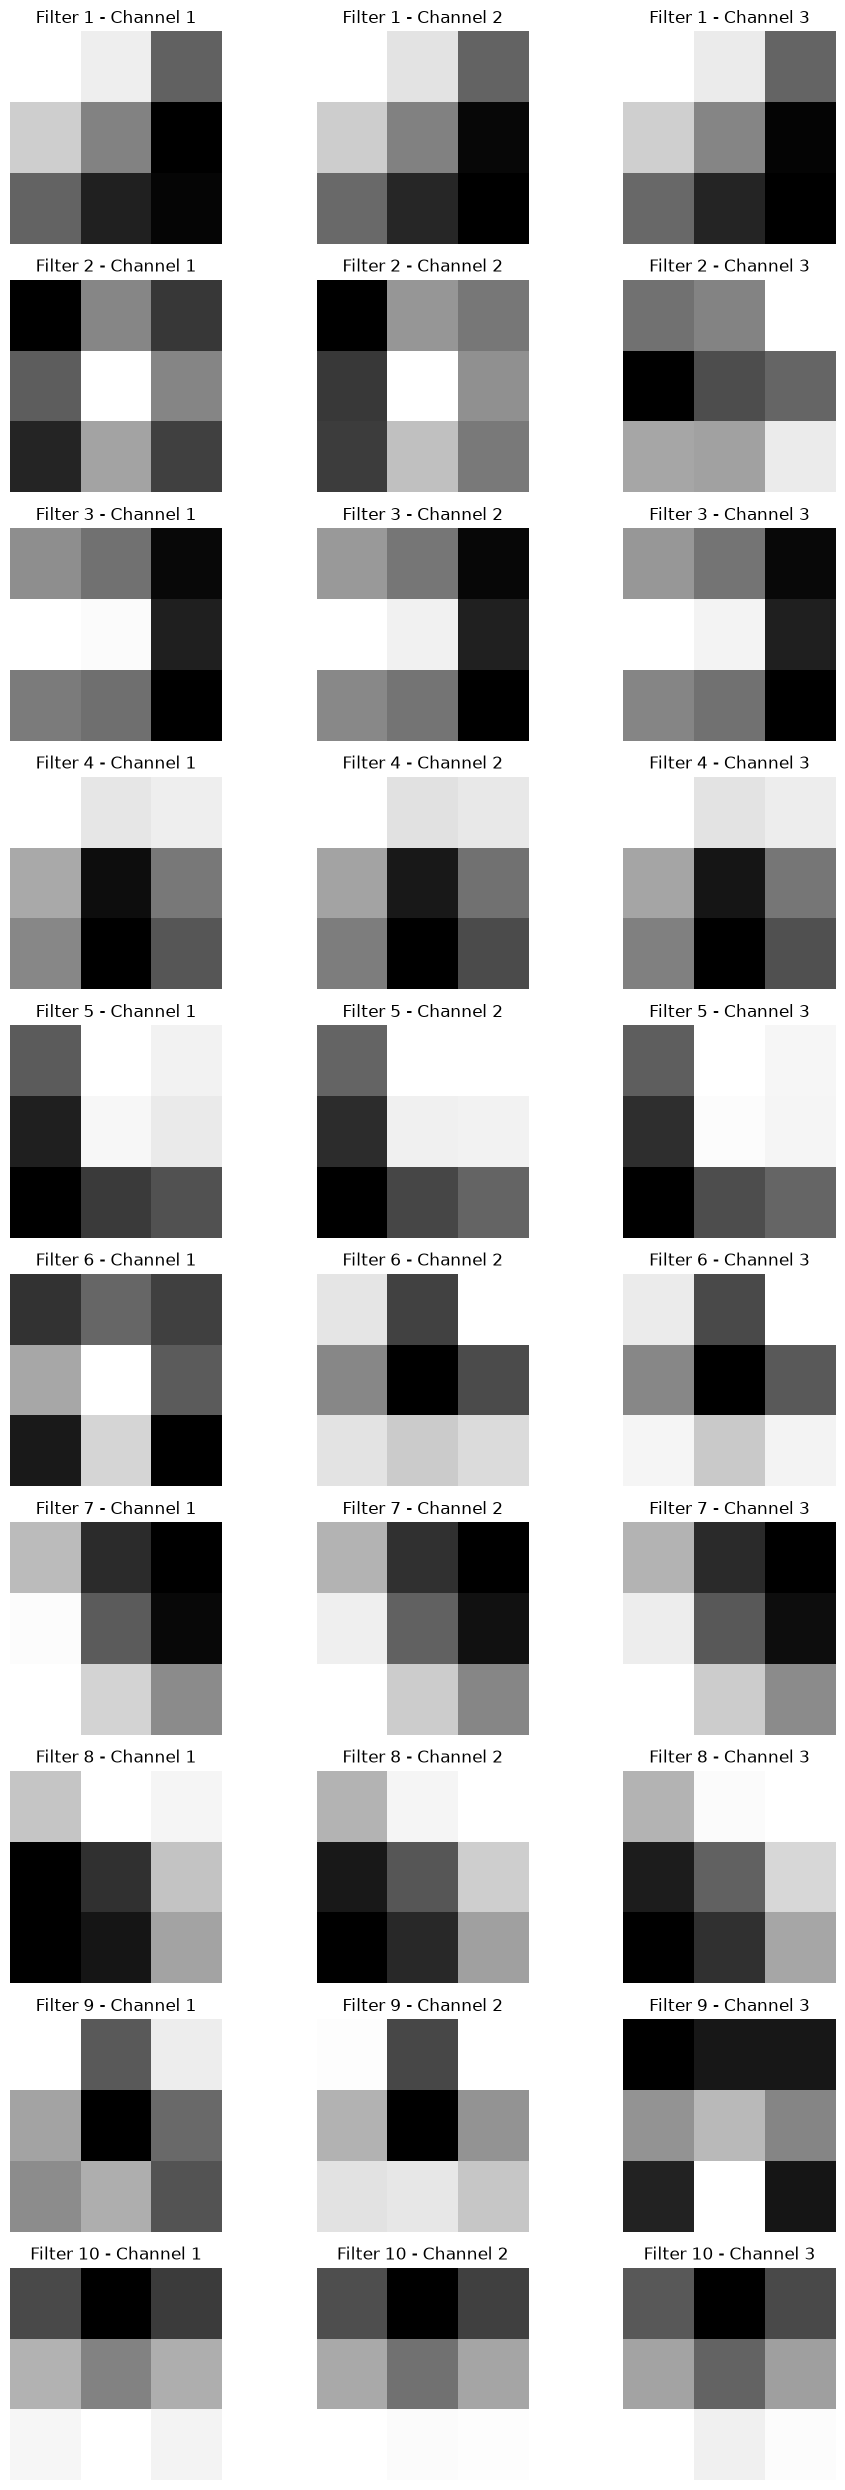

In [ ]:
n_filters = 10      # I only want to visualize the first 10 filters lets say
ix=1        #counter

fig = plt.figure(figsize = (10,25))
for i in range(n_filters):
    f = filters[:,:,:,i]    # (kernel height,kernel width, input channels, number of filters) # I want ith filter
    for j in range(3):      # 3 since there are 3 inpur channels
        plt.subplot(n_filters, 3, ix)       # creates subplot of 10 X 3-> each row = 1 filter 3 hannel RGB
                                            # ix takes it to the next plot
        plt.imshow(f[:,:,j], cmap = 'gray')     # This selects one channel

        plt.title(f"Filter {i+1} - Channel {j+1}")
        plt.axis('off')
        ix+= 1                              # move to next plot

plt.tight_layout()
plt.show()

<h4>Seeing the feature map returns by filters of layer 1</h4>
Filters are not the same as Feature Map <br>
Filters are what we saw above (Basically from get_weights)<br>
Feature maps are the outputs that is returns (Basically set of features)


In [ ]:
from tensorflow.keras import Model
model2 = Model(inputs = model1.inputs, outputs = model1.layers[1].output)

# This creates a new model from your existing VGG16 model.
# Our new model's input is same as that of the Vgg16
# OUr new model's output is same as that of Vgg 16's block1_conv1 output

In [12]:
from tensorflow.keras.preprocessing import image
import numpy as np
img1 = image.load_img("cat_image.jpg", target_size = (224, 224))

img1 = image.img_to_array(img1)
img1 = np.expand_dims(img1, axis = 0)

img1 = preprocess_input(img1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


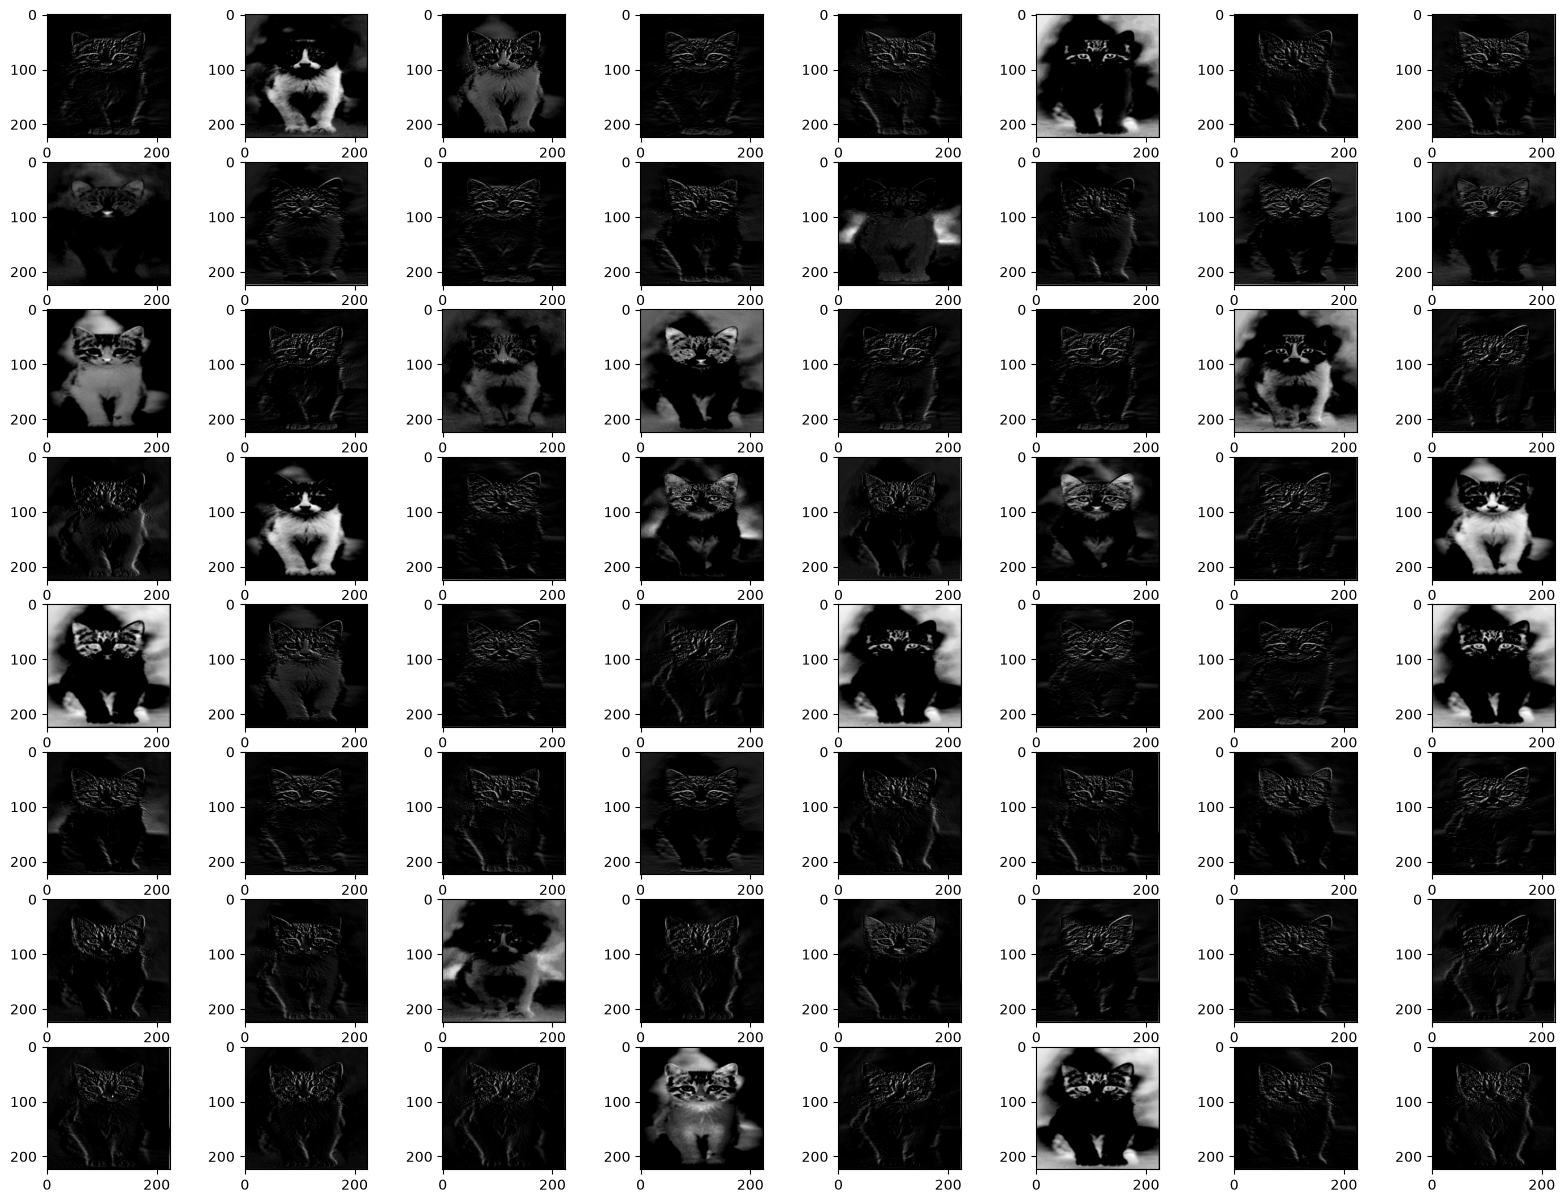

In [ ]:
features = model2.predict(img1)     # gives outputs 224 × 224 × 64 -> height x width x number of filters

fig = plt.figure(figsize=(20,15))
for i in range(1, features.shape[3]+1): # since I want to plot all 64 features  # 1 beacuse plot starts from 1
    plt.subplot(8,8,i)      # My plot ahs 8 row and 8 coulmns and this is plot number i
    plt.imshow(features[0,:,:,i-1], cmap = 'gray')  # shape is (1, 224, 224, 64) 
                                                    # 0th batch full img and i-1 th feature since index start from 0
plt.show()

<h4> Seeing the Feature Maps returned by all convolutional layers</h4>

In [ ]:
model3 = VGG16()    # Again same model

In [ ]:
layer_index = [2, 5, 9, 13, 17]         # These are the conv layers
outputs = [model3.layers[i].output for i in layer_index]        # A list which ahs outputs from every layer

model4 = Model(inputs = model3.inputs, outputs = outputs)       
# Our new model has input same as the vgg16
# Our new model has basically 5 outputs that are basically feature maps of 5 conv layers

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


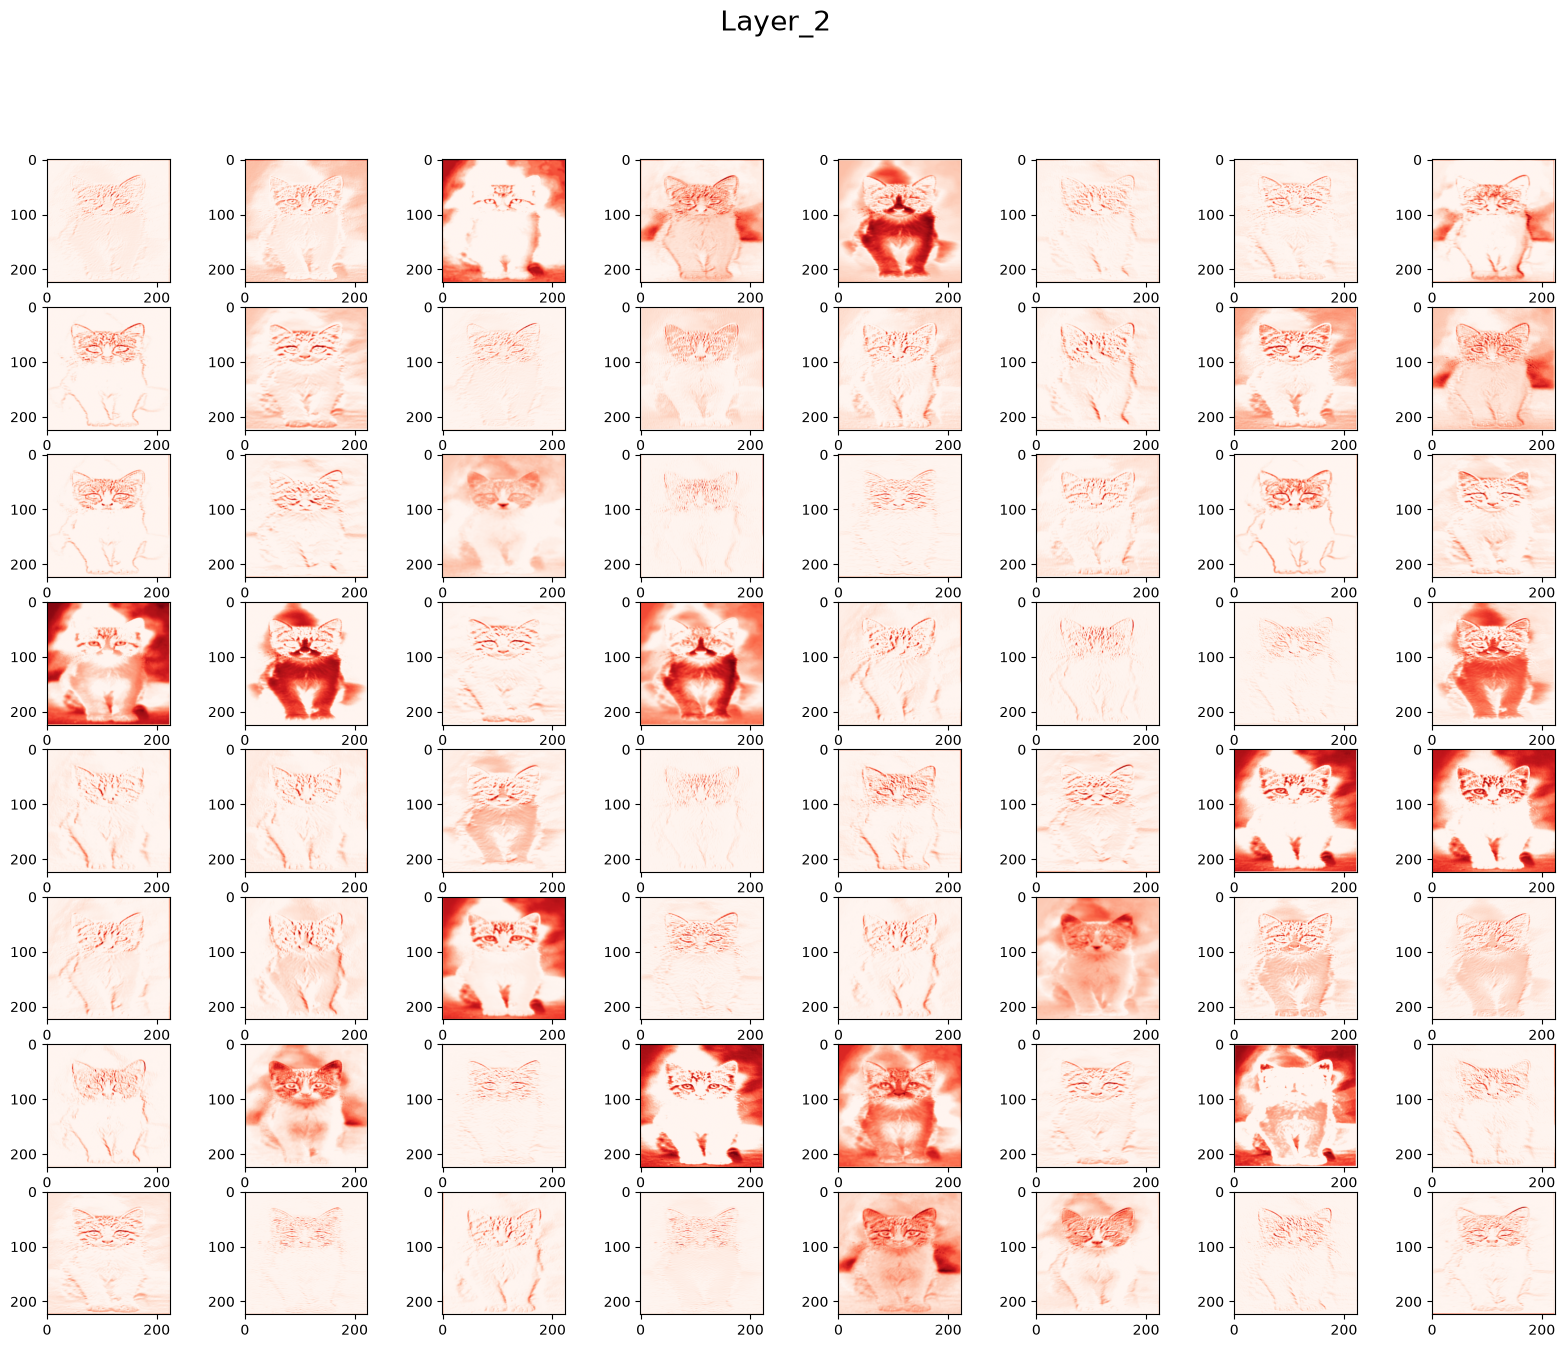

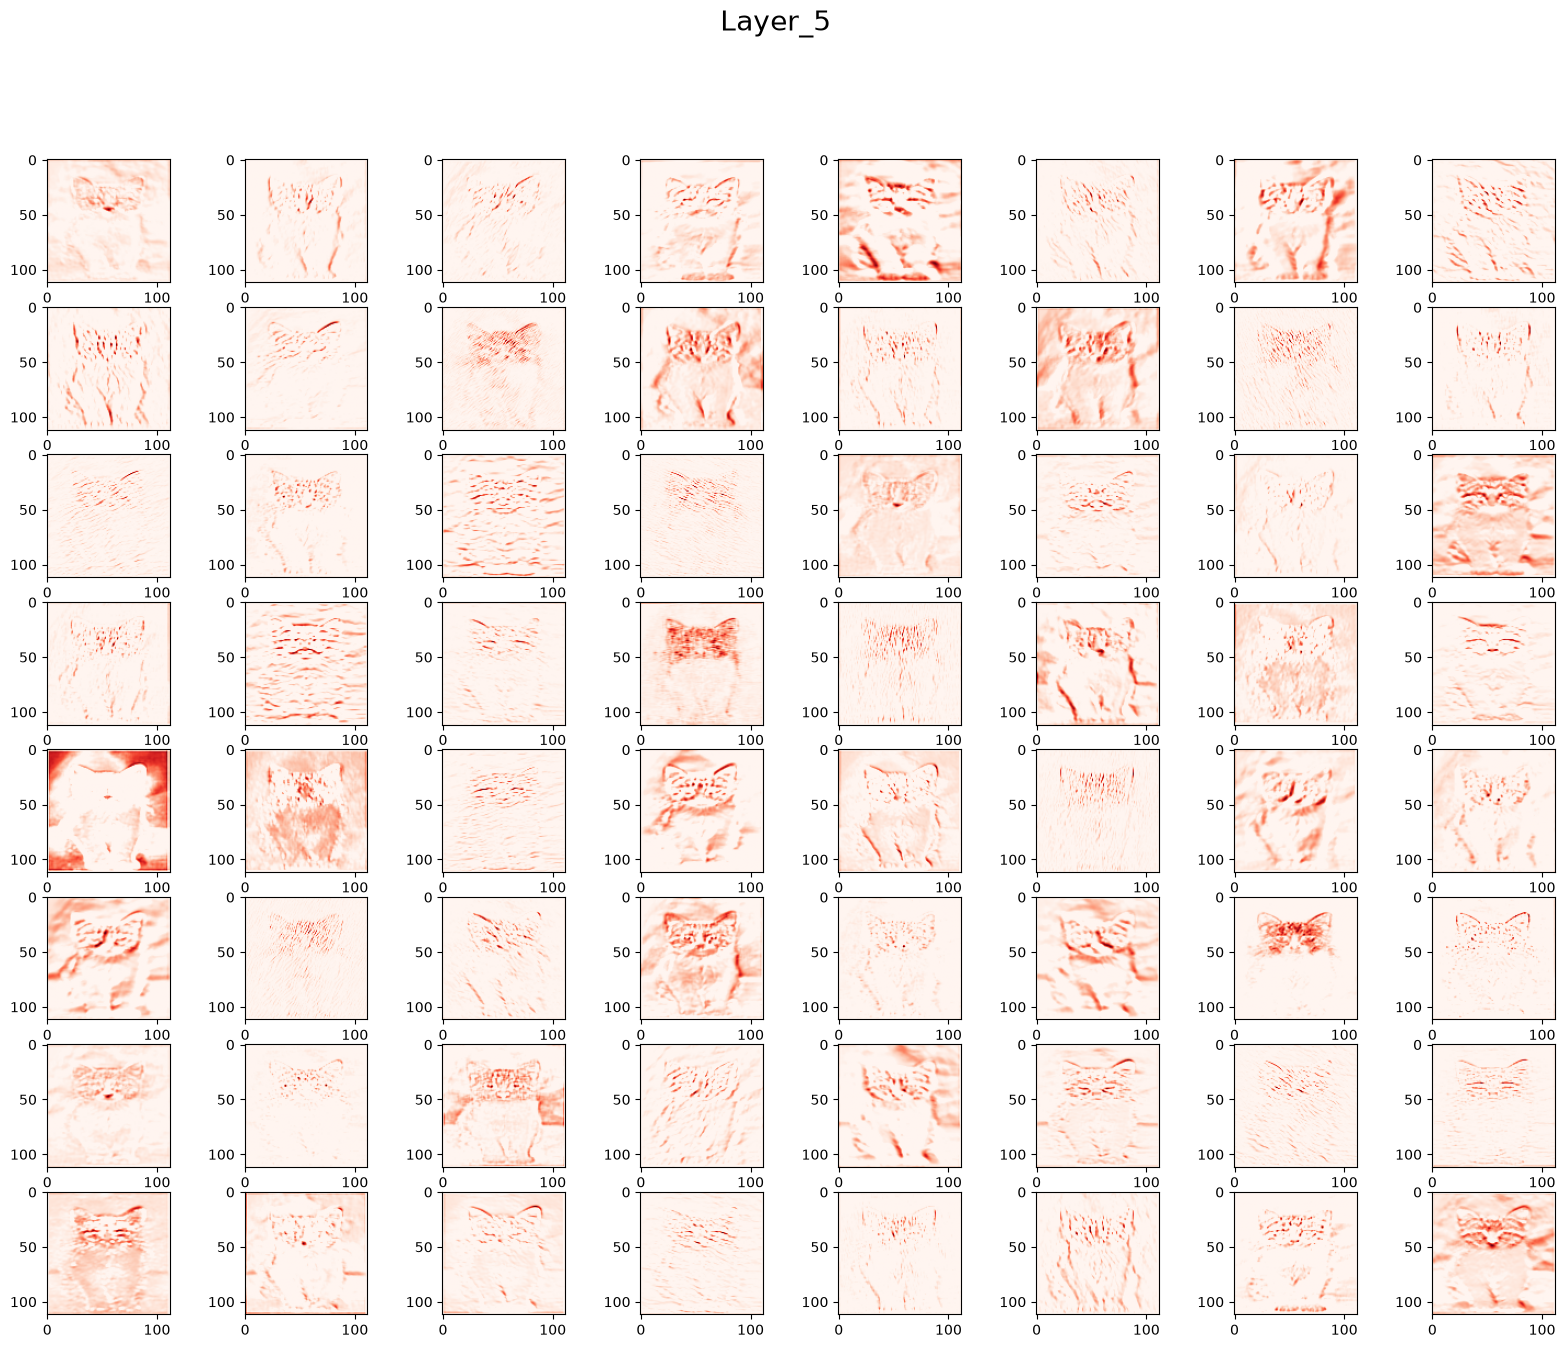

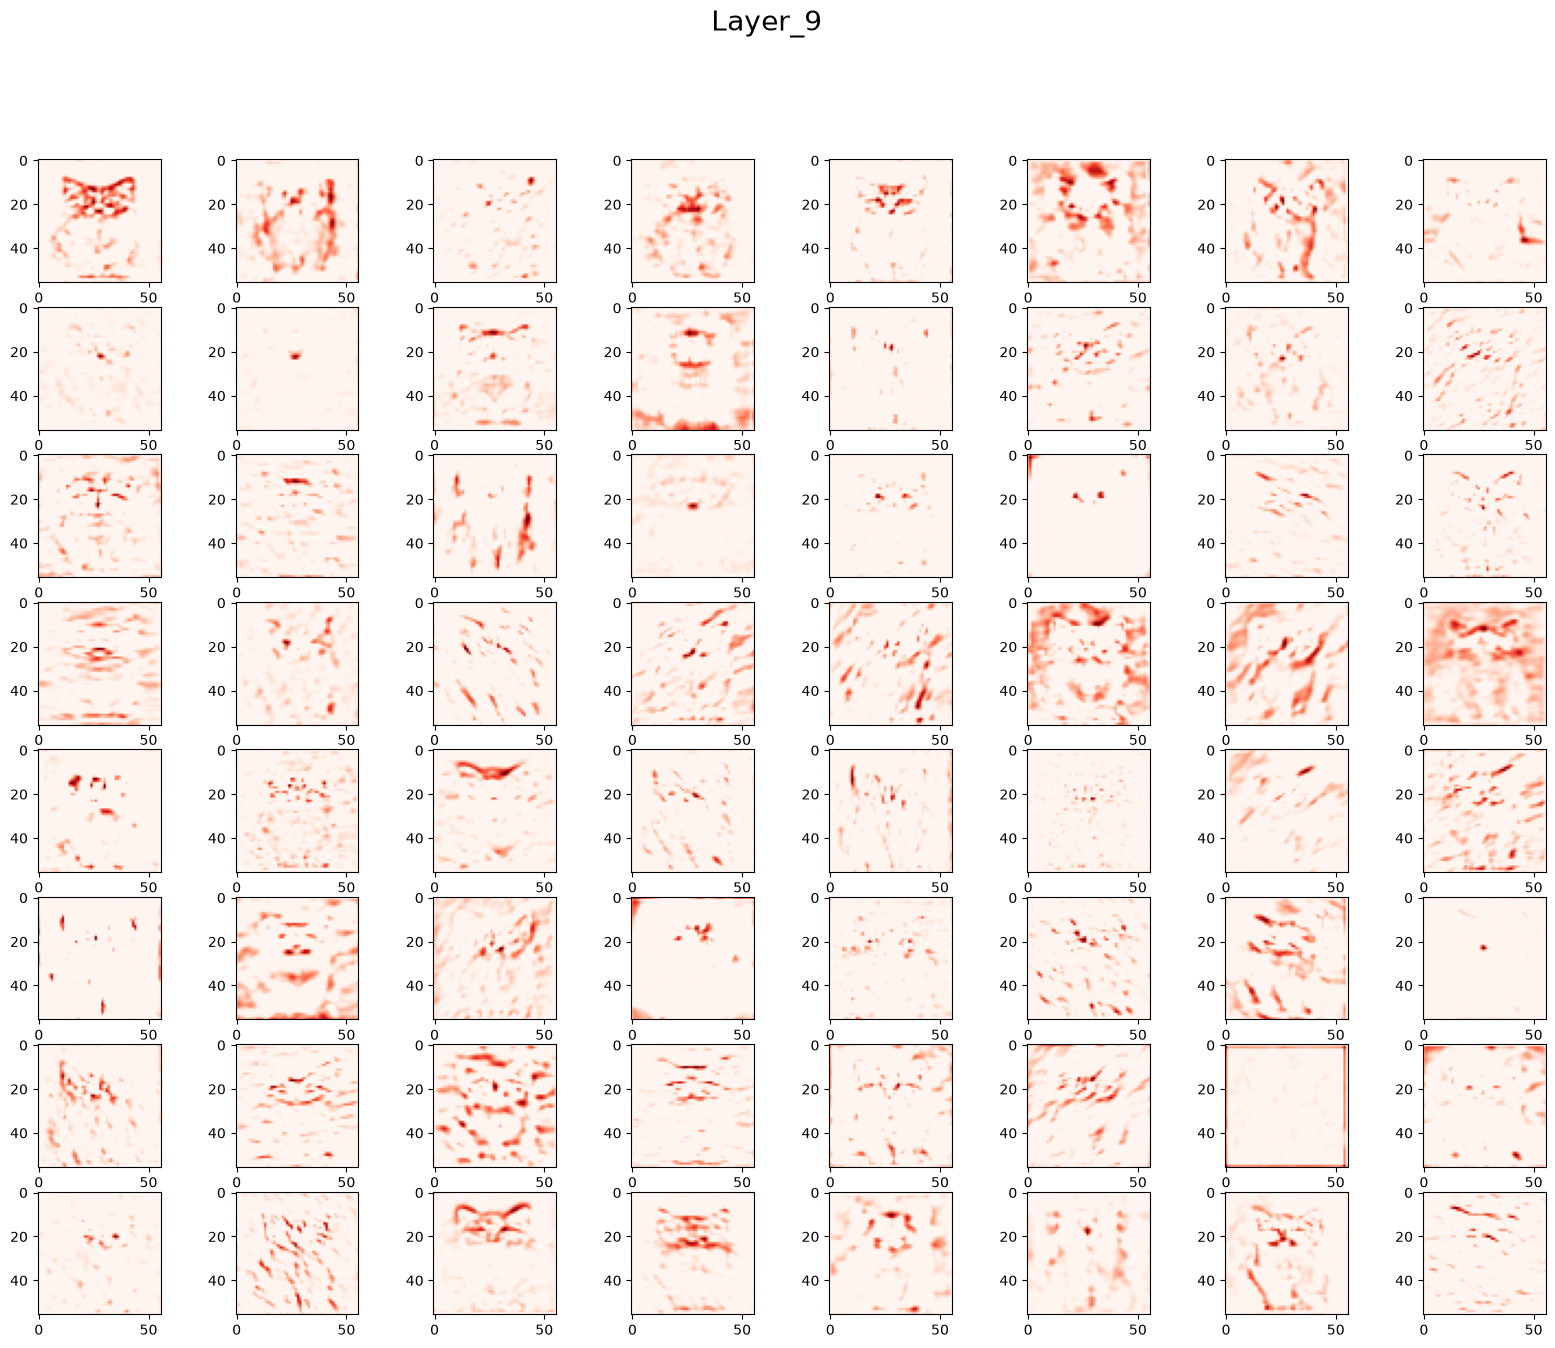

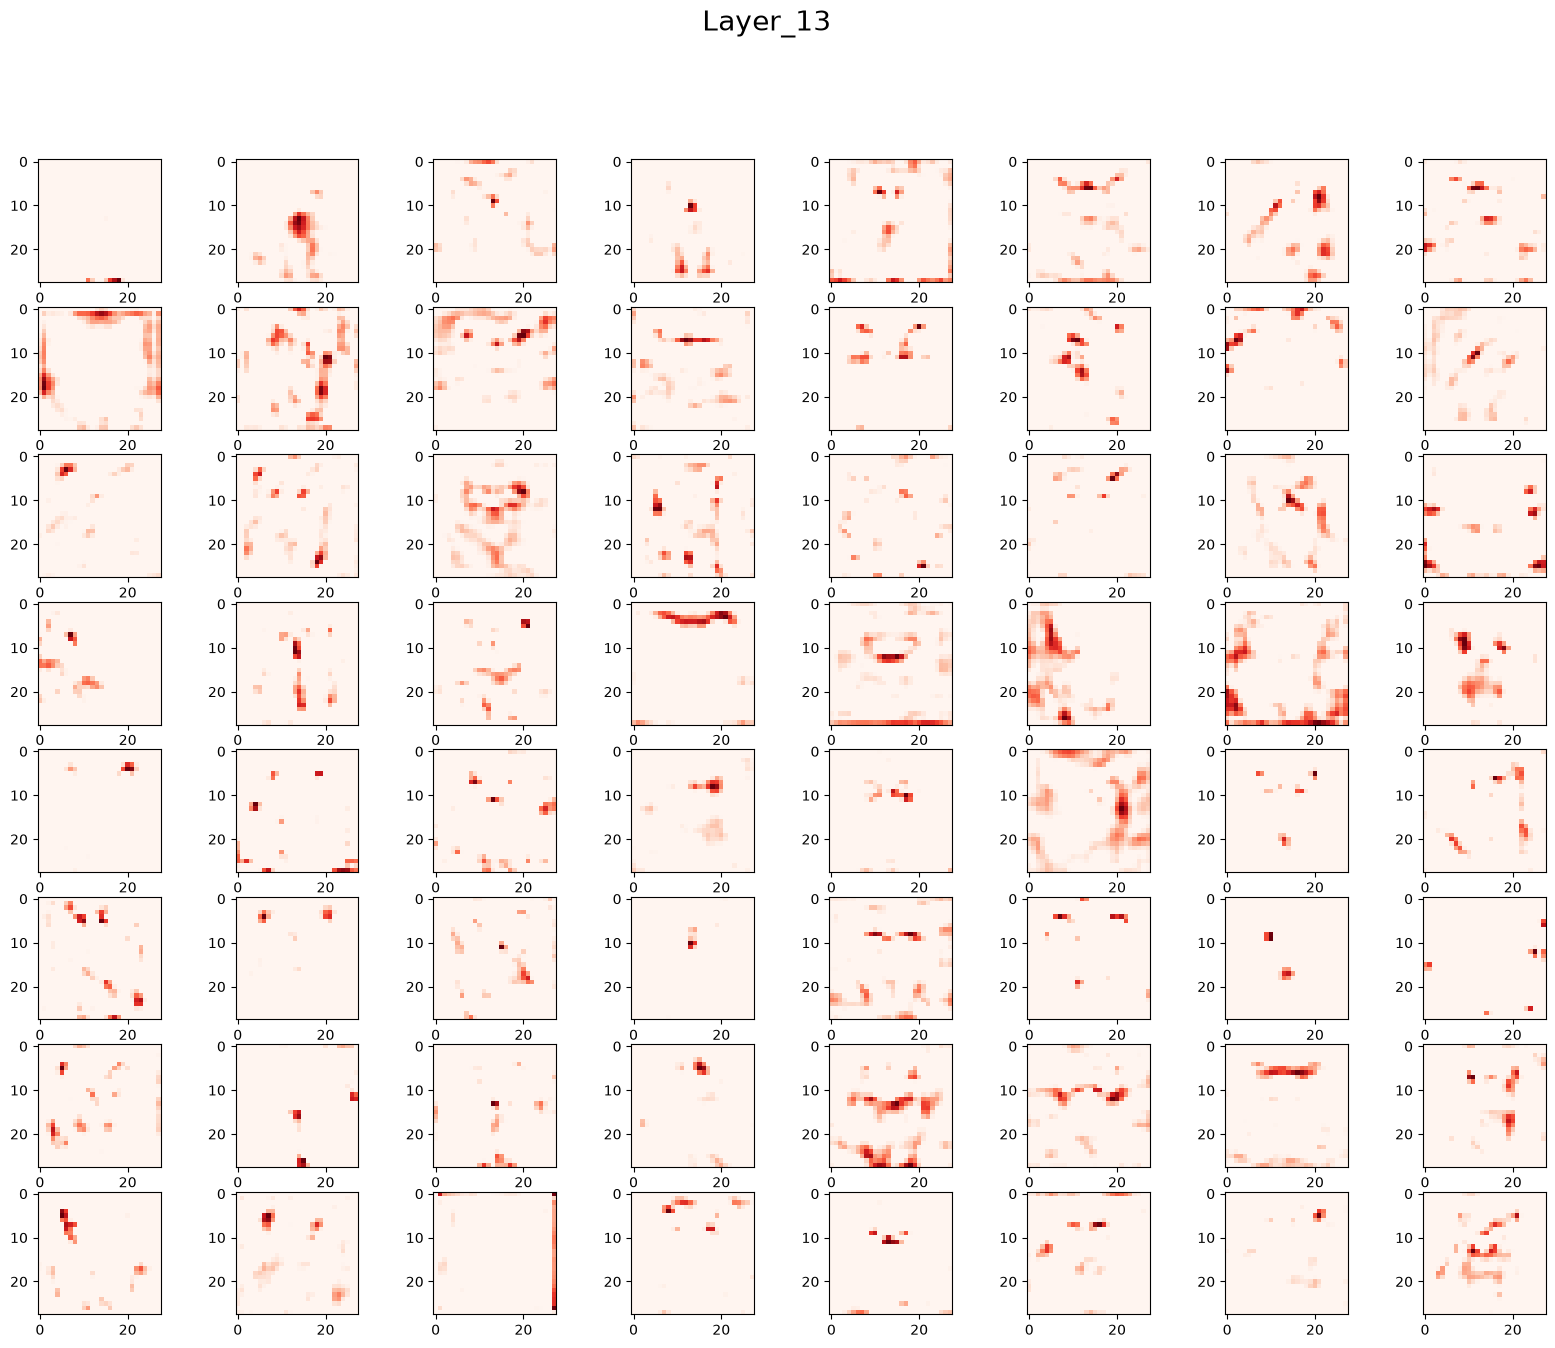

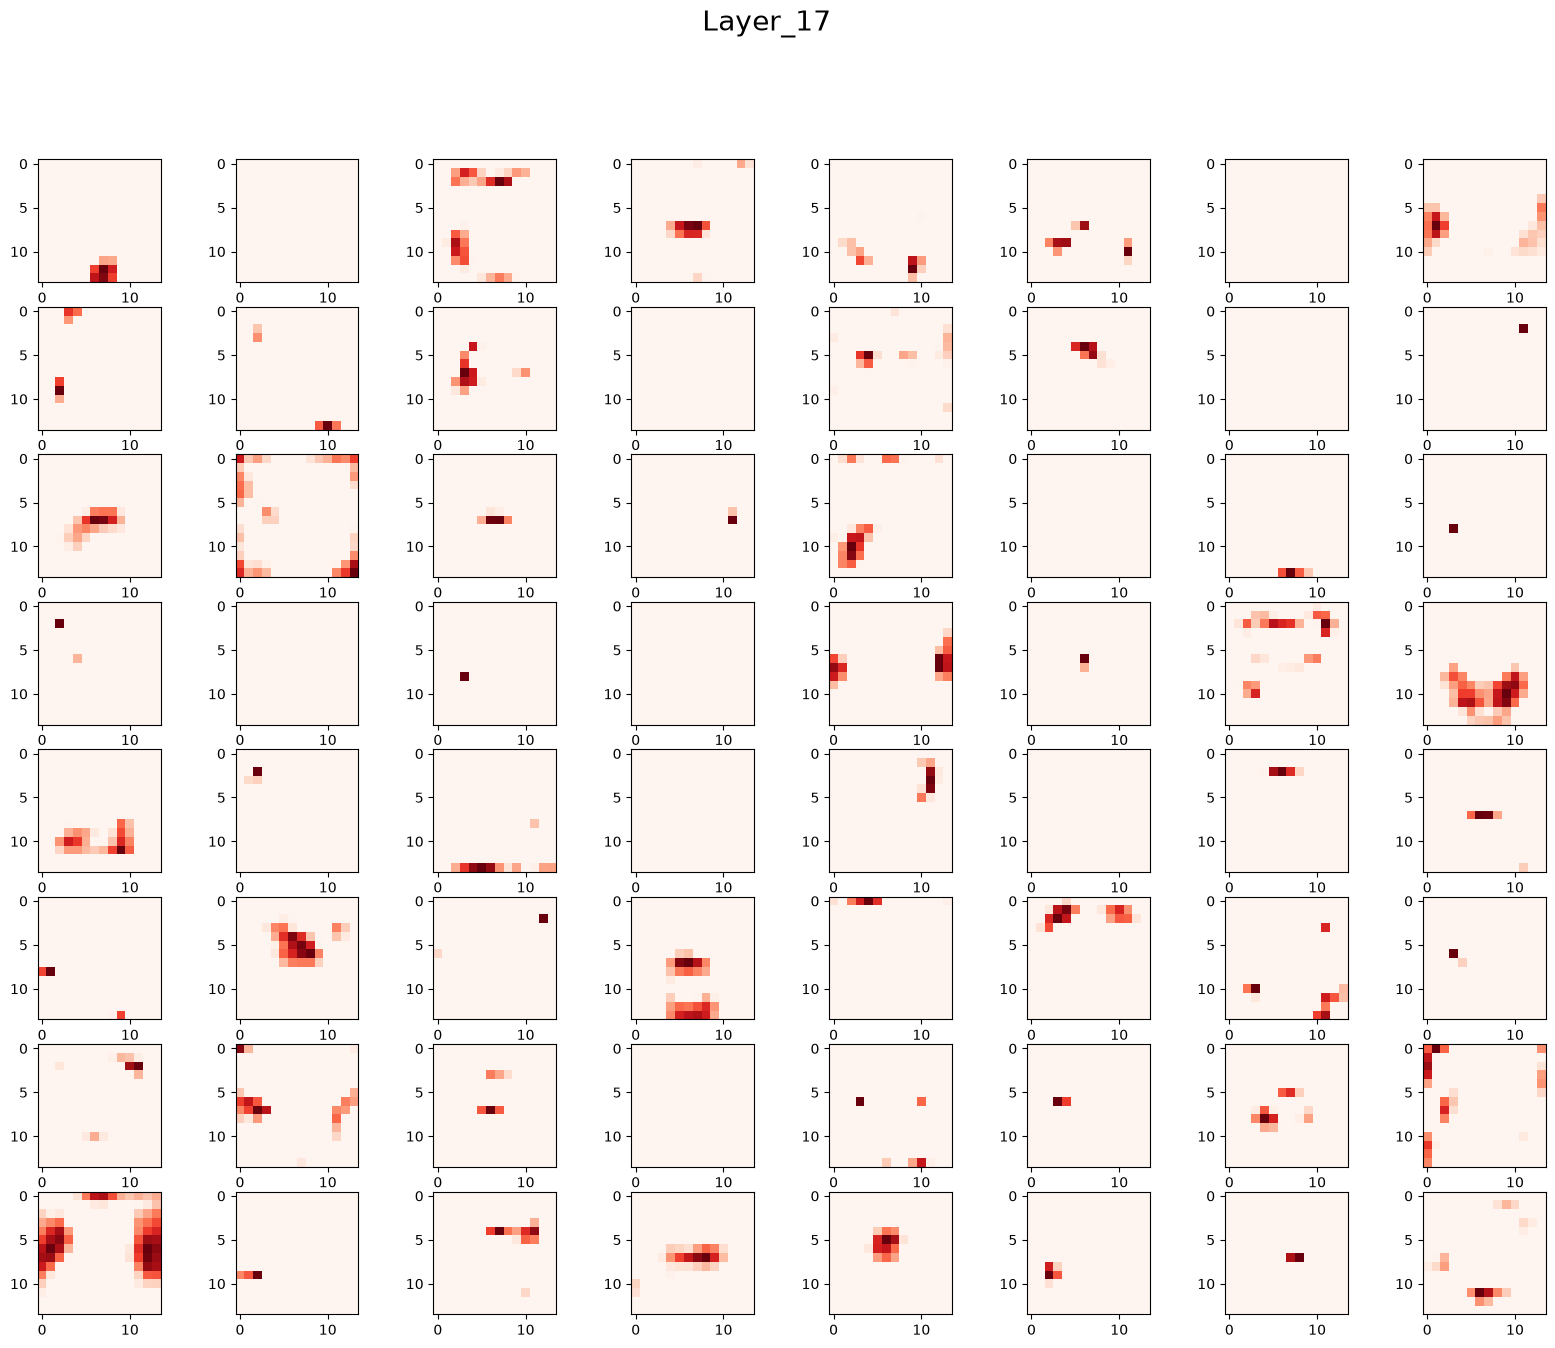

In [ ]:
feature_map = model4.predict(img1)      # feature map is a list which hold op from layer [2, 5, 9, 13, 17]

for i, fmap in zip(layer_index, feature_map):
    fig = plt.figure(figsize=(20,15))
    fig.suptitle("Layer_{}".format(i), fontsize = 20)
    for i in range(1, features.shape[3]+1):
        plt.subplot(8,8,i)
        plt.imshow(fmap[0,:,:,i-1], cmap = 'Reds')

plt.show()